# US_Accidents_EDA

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Importing data set
df=pd.read_csv("US_Accidents.csv")

In [3]:
df.shape

(7728394, 46)

# Data Overview

In [4]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [5]:
df.describe(include='object')

,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,7728394,7728394,7728394,7728394,7728389,7717525,7728141,7728394,7728394,7726479,7728394,7720586,7705759,7608166,7553188,7554935,7705148,7705148,7705148,7705148
unique,7728394,3,6131796,6705355,3761578,336306,13678,1871,49,825094,1,4,2045,941331,24,144,2,2,2,2
top,A-1,Source1,2021-01-26 16:16:13,2021-11-22 08:00:00,A crash has occurred causing no to minimum del...,I-95 N,Miami,Los Angeles,CA,91761,US,US/Eastern,KCQT,2022-03-13 01:53:00,CALM,Fair,Day,Day,Day,Day
freq,1,4325632,225,112,9593,78430,186917,526851,1741433,11247,7728394,3580167,118332,1311,961624,2560802,5334553,5695619,6076156,6377548


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

<Axes: >

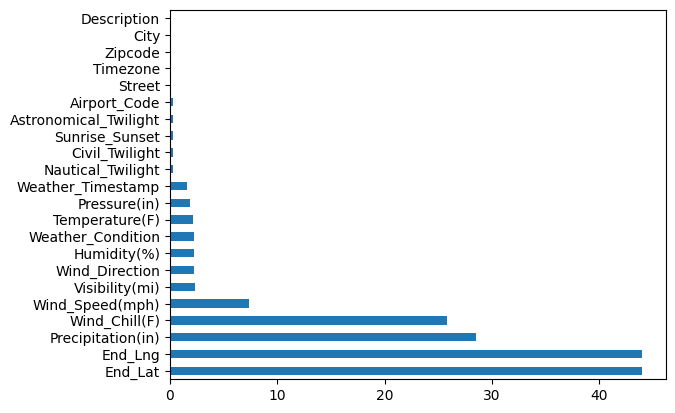

In [7]:
# Indetifying Missing Values
missing_values=((df.isnull().sum() / len(df)) * 100).sort_values(ascending=False)
missing_values[missing_values > 0].plot(kind='barh')

In [9]:
# Show only duplicated rows
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [10]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [11]:
# create columns from 'Start_Time'
df['Start_Date']=df['Start_Time'].str.split(" ").str.get(0)
df['Start_time']=df['Start_Time'].str.split(" ").str.get(1)

In [12]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')
df['Start_time'] = pd.to_datetime(df['Start_time'], format='%H:%M:%S',errors='coerce')

# Data Analysis & Visualization

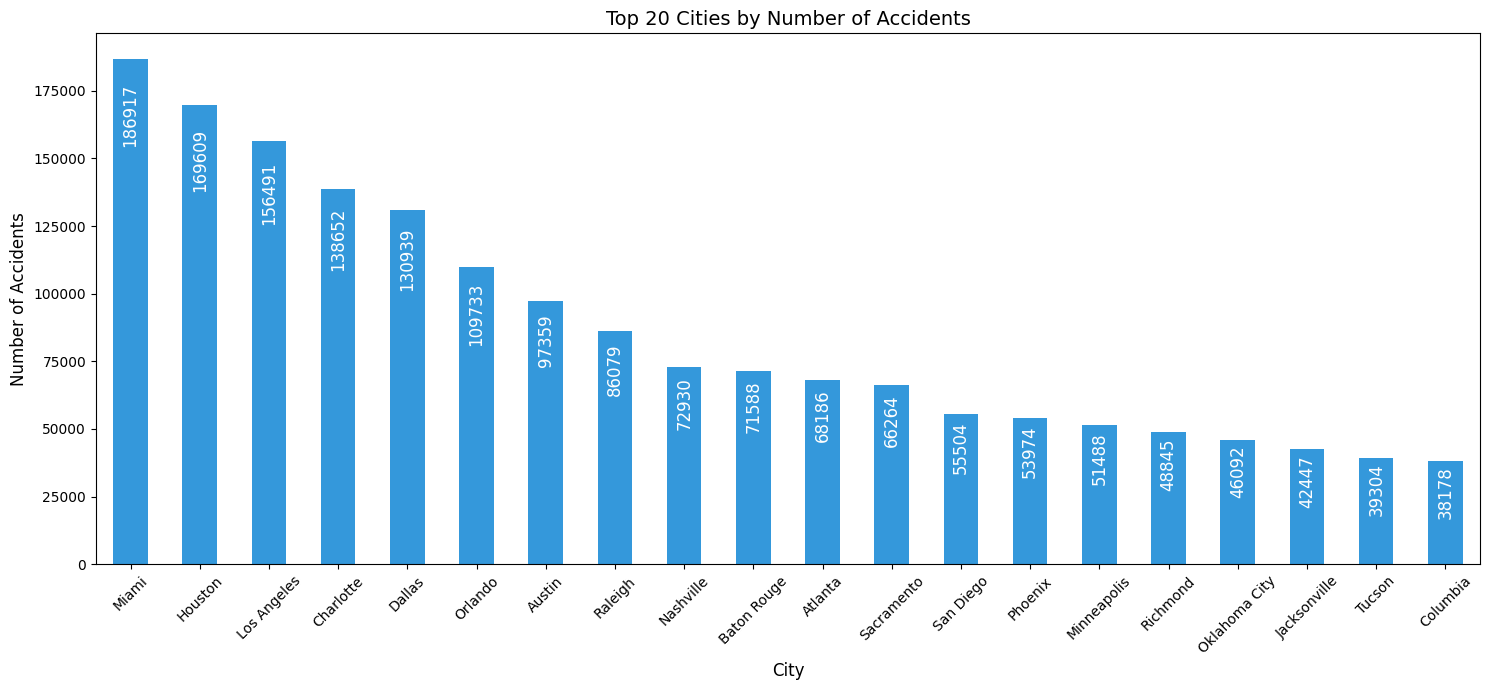

In [13]:
# Top 20 cities by accident

cities_by_accident = df.City.value_counts()[:20]

plt.figure(figsize=(15, 7))
ax = cities_by_accident.plot(kind='bar', color="#3498db")
plt.title("Top 20 Cities by Number of Accidents", fontsize=14)
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)

# Add data labels inside the end of each bar
for i, val in enumerate(cities_by_accident.values):
    ax.text(i, val - (val * 0.05),  # a little below the bar top
            str(val),
            ha='center',
            va='top',
            rotation=90,
            fontsize=12,
            color='white')  # white text inside colored bars

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

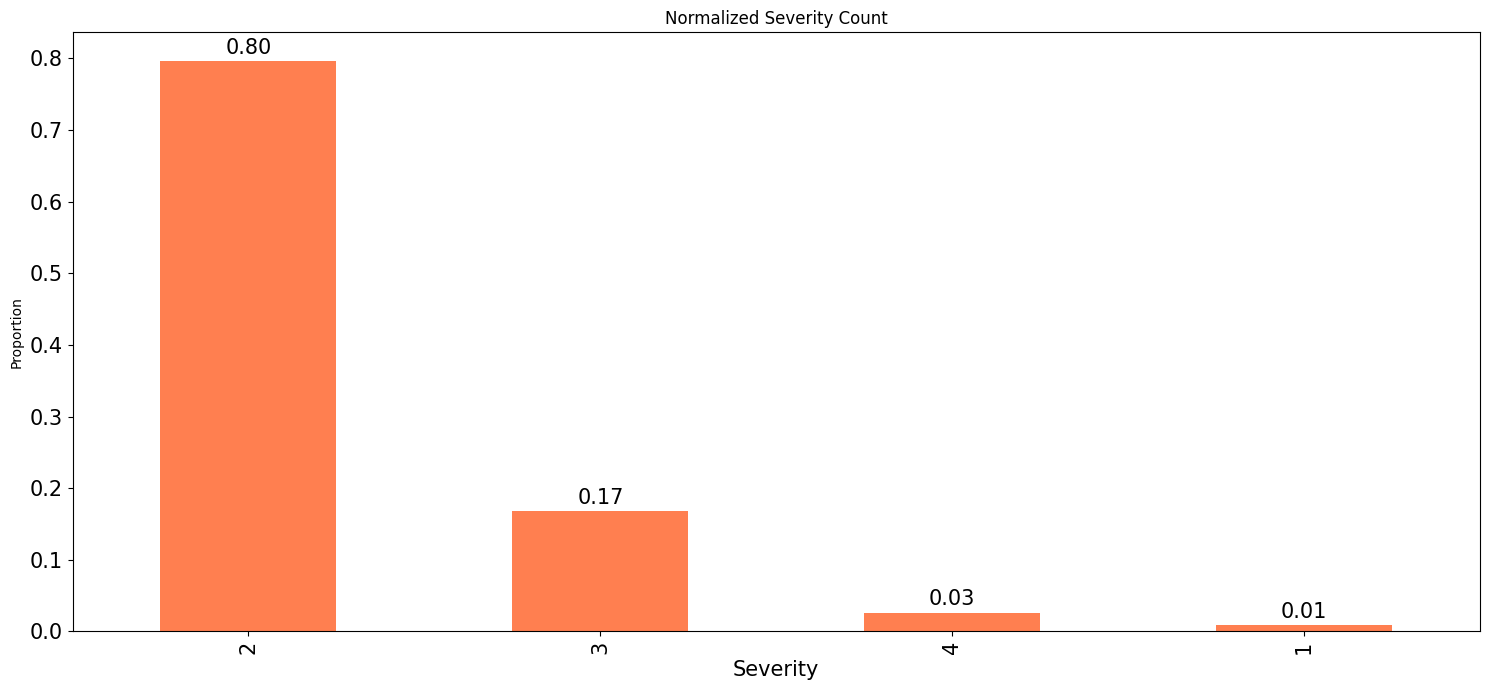

In [14]:
severity_count = df.Severity.value_counts(normalize=True)
plotting = severity_count.plot(kind='bar', figsize=(15,7), color= '#FF7F50',fontsize=15)

# Add text labels on top of each bar
for i, v in enumerate(severity_count):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize= 15)

plt.xlabel('Severity', fontsize=15)
plt.ylabel('Proportion')
plt.title('Normalized Severity Count')
plt.tight_layout()
plt.show()

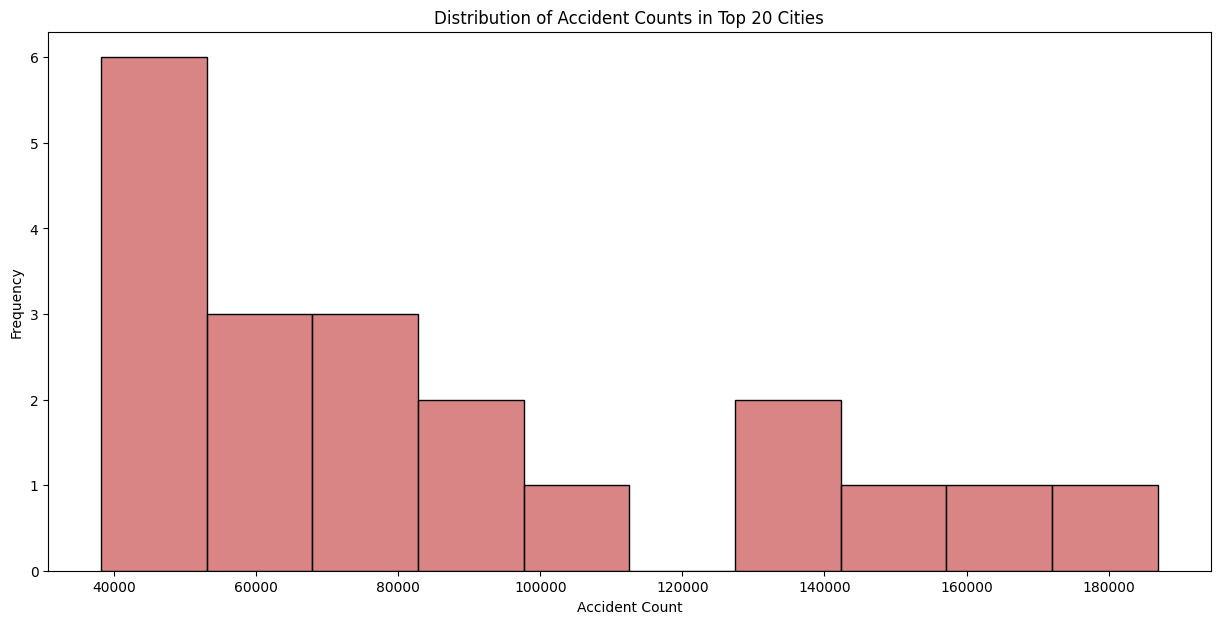

In [15]:
# Distribution of the accidents

plt.figure(figsize=(15, 7))

sns.histplot(cities_by_accident, color='#CD5C5C', bins=10)
plt.title("Distribution of Accident Counts in Top 20 Cities")
plt.xlabel("Accident Count")
plt.ylabel("Frequency")
plt.show()

# Inference:
-> The distribution of accident counts across the top 20 cities is right-skewed, with a clear majority of cities (6 out of 20) having relatively lower counts (around 40,000–60,000 accidents), while a small   number of cities experience significantly higher volumes (up to 180,000+).

-> A long right tail indicates the presence of outlier cities with exceptionally high accident burdens, likely representing major urban centers or high-risk traffic zones that disproportionately drive national accident statistics.

-> This skewness highlights the importance of targeted interventions in high-accident outlier cities to achieve the largest reduction in overall incidents.

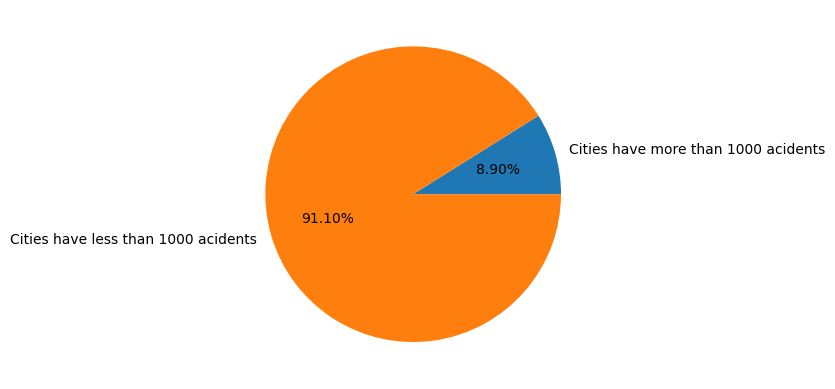

In [16]:
# accident_city_ratio

cities_count= df.City.value_counts().reset_index()

high_accident_cities= cities_count['count'][cities_count['count'] >= 1000].count() / len(df.City.unique())
low_accident_cities= cities_count['count'][cities_count['count'] < 1000].count()/ len(df.City.unique())

accident_city_ratio= pd.Series({"Cities have more than 1000 acidents":high_accident_cities,
                "Cities have less than 1000 acidents":low_accident_cities})

accident_city_ratio.plot(kind='pie', autopct='%0.2f%%')
plt.show()

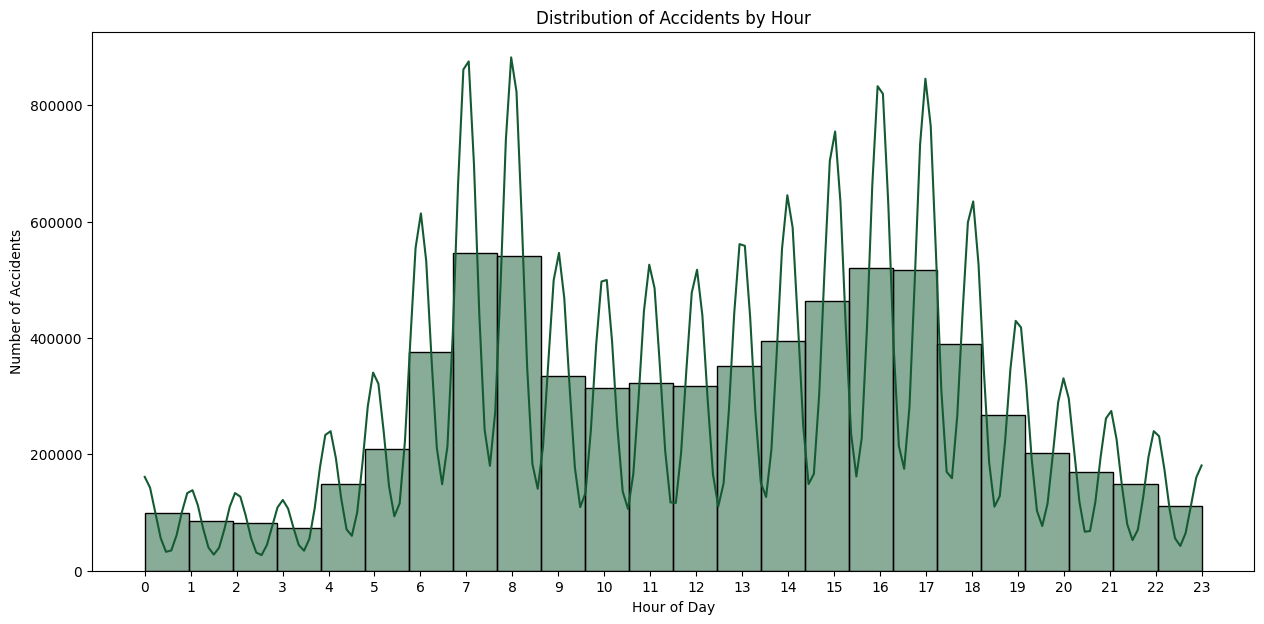

In [17]:
# Time when max accident occours
plt.figure(figsize=(15,7))

sns.histplot(df['Start_time'].dt.hour, bins=24, color='#145a32', edgecolor='black', kde=True)
plt.title("Distribution of Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.show()

# Inference:
-> Accidents show a clear bimodal pattern with two distinct peaks: the highest around 7–8 AM (morning rush hour) and a second major peak around 5–6 PM (evening rush hour), reflecting typical commuting times.

-> The number of accidents remains significantly elevated from 6 AM to 6 PM, indicating that the majority of incidents occur during daylight and peak traffic hours rather than late at night.

-> Nighttime hours (midnight to 5 AM) exhibit the lowest accident counts, with a sharp drop after 9 PM and minimal activity between 1–4 AM, suggesting reduced traffic volume and lower risk during these periods.

-> The pronounced spikes at commuting transition times highlight the strong influence of rush-hour congestion and human behavior patterns on accident frequency.

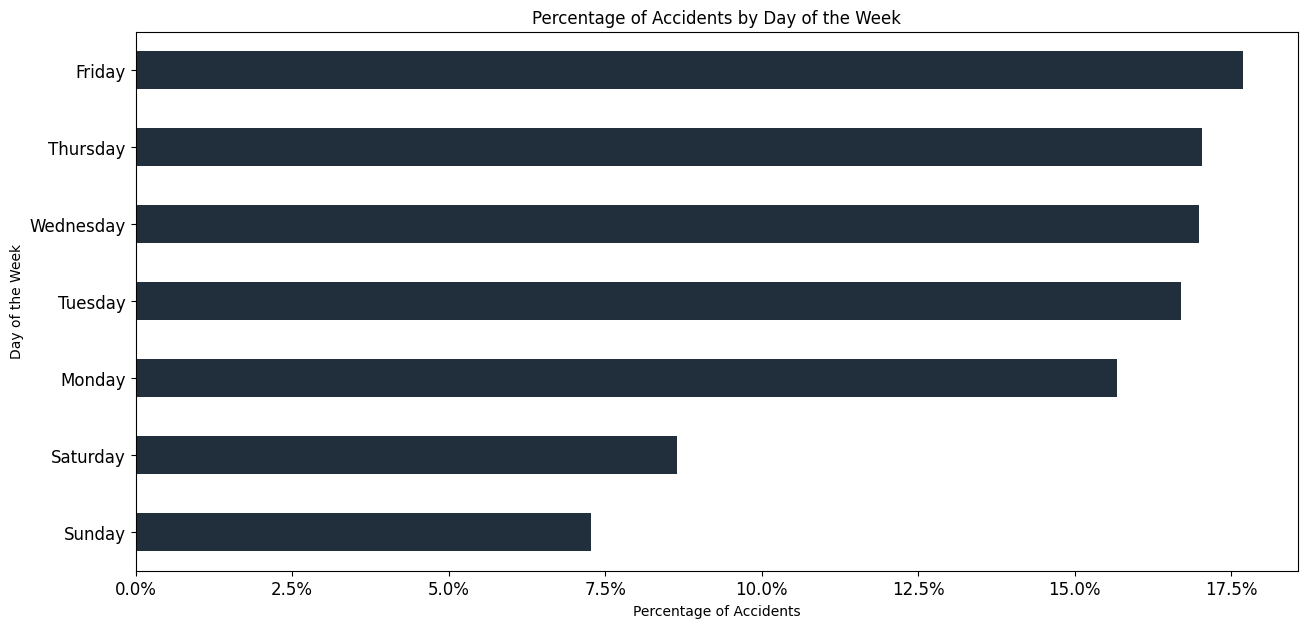

In [18]:
# Day on which max accident occurs
plt.figure(figsize=(15,7))

df['Start_Date'].dt.day_name().value_counts(normalize=True).sort_values().plot(
    kind='barh',
    color='#212f3d',fontsize=12)

plt.title("Percentage of Accidents by Day of the Week")
plt.xlabel("Percentage of Accidents")
plt.ylabel("Day of the Week")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))  # Convert to percentage
plt.show()

# Inference:

-> Fridays record the highest percentage of accidents (~17–17.5%), making it the most accident-prone day of the week, likely due to end-of-week fatigue, social activities, and increased evening travel.

-> Weekdays (Monday through Friday) consistently show higher accident rates (all above ~12.5–17.5%) compared to weekends, reflecting greater commuting volumes and work-related travel during the business week.

-> Weekends, particularly Sunday, have the lowest accident share (~7–8%), followed by Saturday (~10%), suggesting significantly reduced traffic and fewer high-risk trips on non-working days.

-> The clear weekday-to-weekend decline highlights the strong influence of commuting patterns and daily routines on accident frequency, with potential for targeted safety campaigns focused on Thursday–Friday peaks.

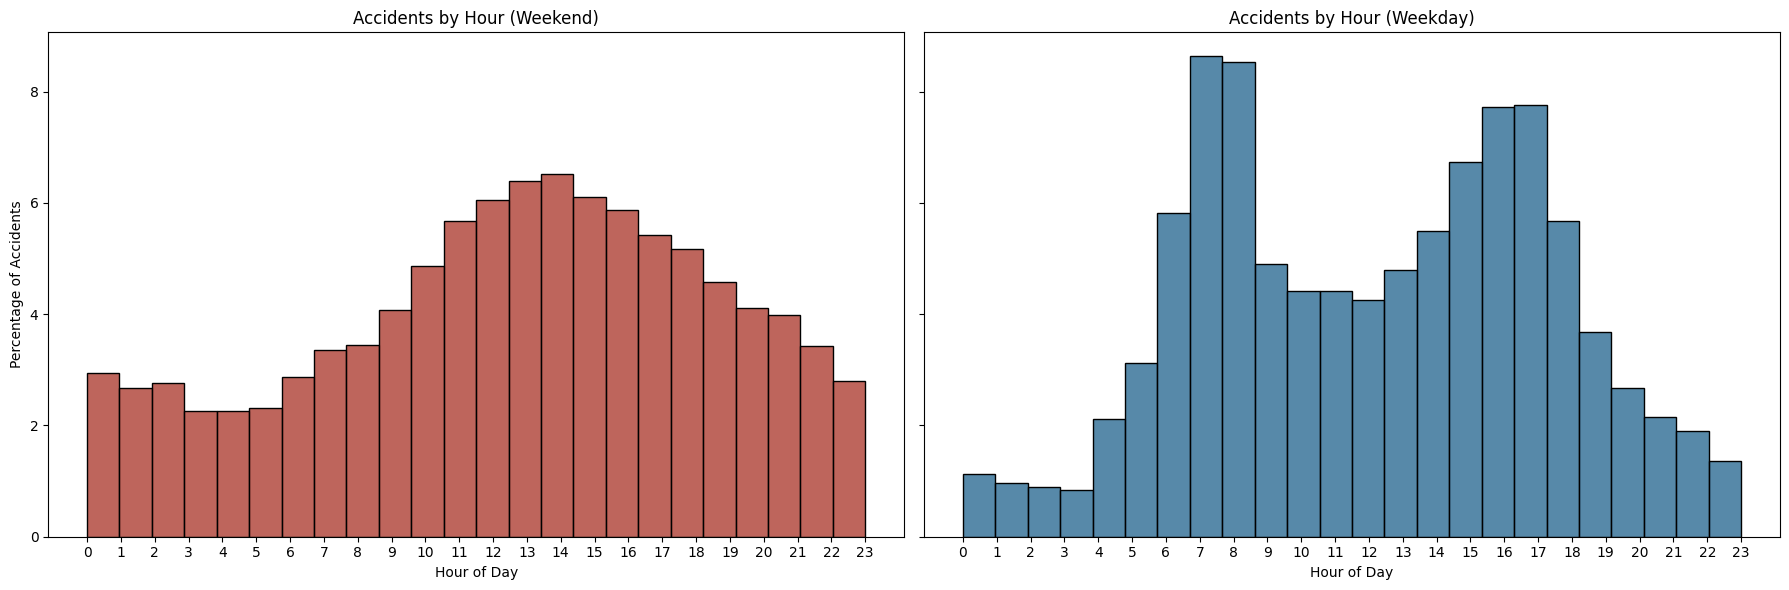

In [19]:
# is the distribution of accidents by hour the same on weekends as on weekdays

df['day_name'] = df['Start_Date'].dt.day_name()
df['hour'] = df['Start_time'].dt.hour

weekend_mask = df['day_name'].isin(['Saturday', 'Sunday'])
weekday_mask = ~weekend_mask

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.histplot(df[weekend_mask]['hour'], bins=24, color='#a93226', edgecolor='black', stat='percent', ax=axes[0])
axes[0].set_title("Accidents by Hour (Weekend)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Percentage of Accidents")
axes[0].set_xticks(range(0, 24))

sns.histplot(df[weekday_mask]['hour'], bins=24, color='#1f618d', edgecolor='black', stat='percent', ax=axes[1])
axes[1].set_title("Accidents by Hour (Weekday)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("")  # Shared y-axis
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Inference:

-> Weekday accidents display a strong bimodal distribution with clear morning (7–9 AM) and evening (4–6 PM) rush-hour peaks, reflecting heavy commuting traffic and work-related travel patterns.

-> Weekend accidents follow a much smoother, unimodal pattern that gradually rises from mid-morning (~10 AM), reaches a broad plateau between 12 PM and 6 PM, and slowly declines into the evening — indicating more leisure, shopping, and social travel spread throughout the day.

-> Nighttime hours (midnight–5 AM) show noticeably higher relative accident percentages on weekends (~2.5–3%) compared to weekdays (~1% or less), likely due to increased nightlife, alcohol-related driving, and fewer people on the roads.

-> The weekday peaks are significantly sharper and more pronounced than the weekend distribution, highlighting that structured commuting behavior drives the highest-risk time windows, while weekends exhibit more dispersed and moderate risk throughout daylight hours.

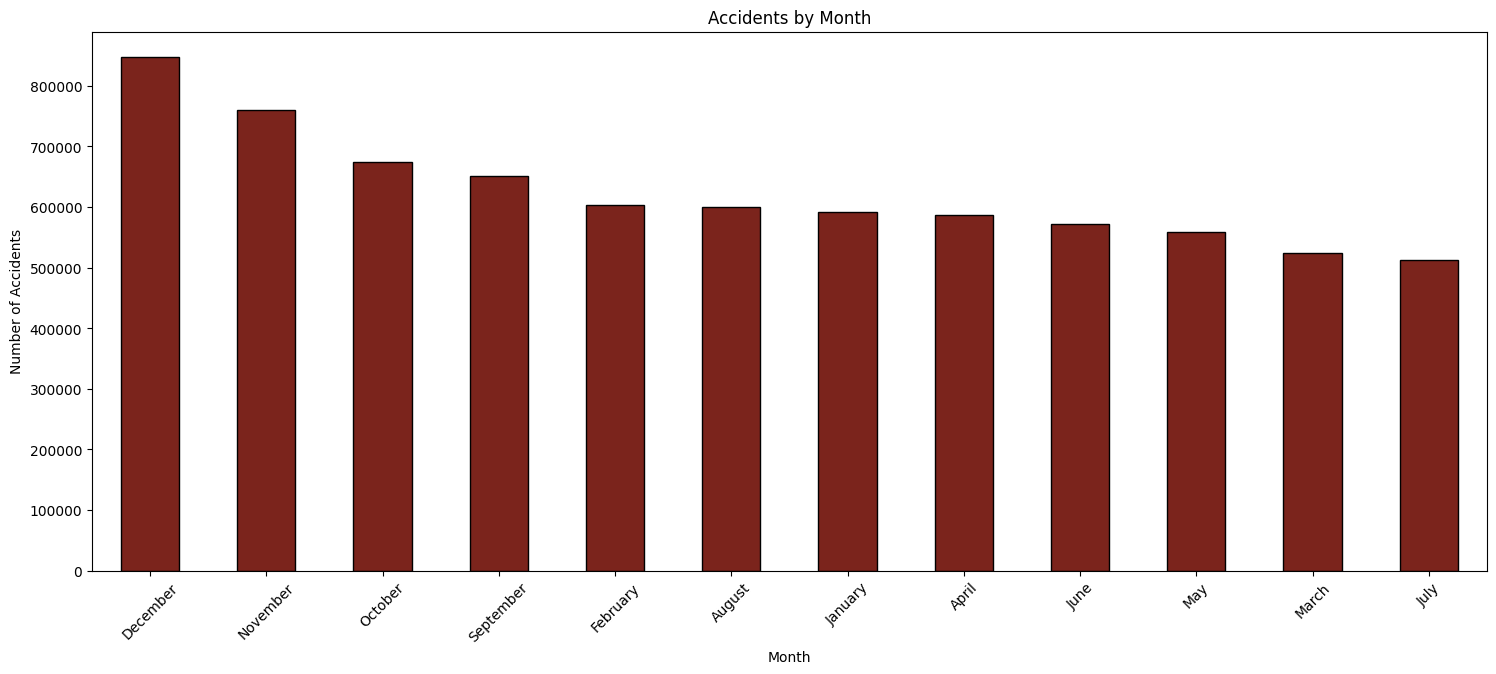

In [24]:
# Months with max accident occors
date_range= df[(df["Start_Date"] >= '2016-01-14') & (df["Start_Date"] <= '2022-12-31')]
month_counts= date_range["Start_Date"].dt.month_name().value_counts()

plt.figure(figsize=(18, 7))
month_counts.plot(kind='bar', color='#7b241c', edgecolor='black')
plt.title("Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

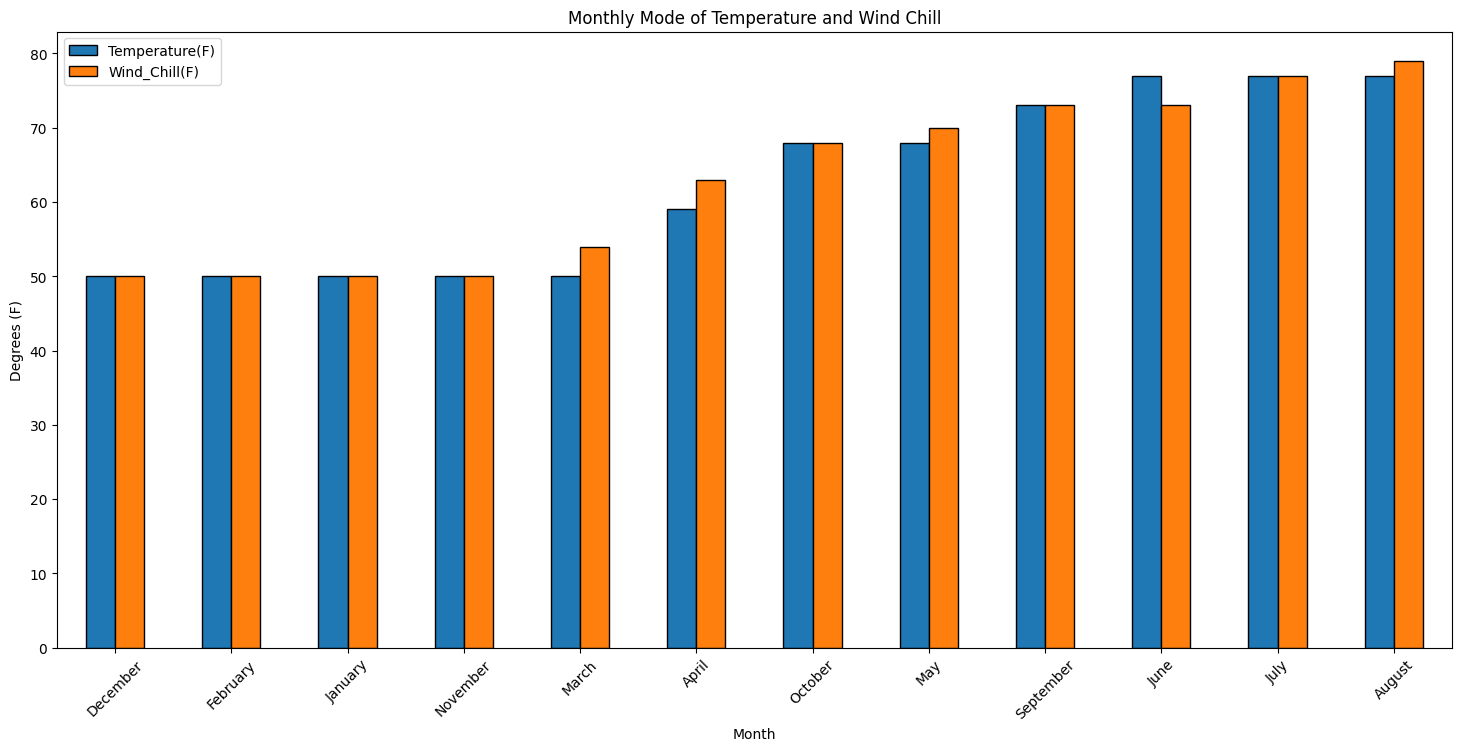

In [23]:
# Median temperature of each month

df['Month'] = df['Start_Date'].dt.month_name()  # extract month from datetime

# Group by Month and calculate mode for each column
mode_df = df.groupby('Month')[['Temperature(F)', 'Wind_Chill(F)']].agg(lambda x: x.mode().iloc[0]
          ).sort_values(['Temperature(F)', 'Wind_Chill(F)'],ascending=[True,True])

mode_df.plot(kind='bar', figsize=(18,8), edgecolor='black')
plt.title("Monthly Mode of Temperature and Wind Chill")
plt.ylabel("Degrees (F)")
plt.xticks(rotation=45)
plt.show()

# Inference:

-> Wind chill closely tracks actual temperature in cooler months (November–March), with identical modes (~50°F) in most winter periods, indicating minimal wind impact during cold seasons.

-> From spring onward (April–August), wind chill becomes noticeably higher than temperature in several months (differences of 4–7°F in April, June, July, August), suggesting stronger wind effects during warmer periods when perceived cold is amplified by breeze.

-> The largest wind chill premium occurs in summer months (June–August, up to 7°F higher in August), likely due to higher average wind speeds enhancing evaporative cooling even at moderate-to-high temperatures.

-> Overall, wind chill exceeds temperature in 5 out of 12 months (primarily warmer ones), while equaling it in the remaining 7 — highlighting that perceived temperature feels colder than actual readings mainly during transitional and peak warm seasons.

[]

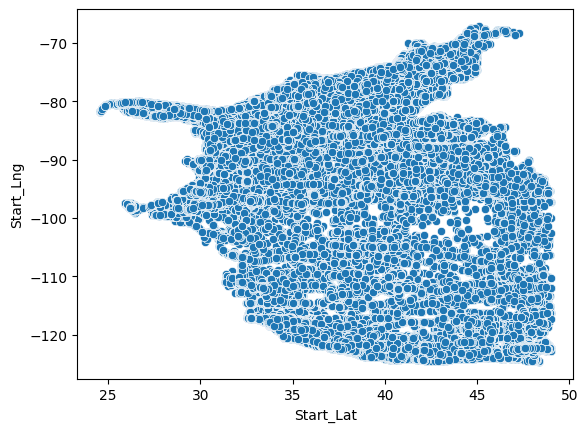

In [25]:
sns.scatterplot(x=df['Start_Lat'], y=df['Start_Lng'])
plt.plot()

In [26]:
# Top 500 Accident prone cities
count_of_cities= df.City.value_counts().reset_index()
accident_prone_cities= count_of_cities[count_of_cities['count']>=1000].sort_values('count',ascending=False)['City'][:500]
# accident_prone_cities
df_of_accident_prone_cities= df[df['City'].isin(accident_prone_cities)]

In [ ]:
heat_data = df_of_accident_prone_cities[['Start_Lat', 'Start_Lng']].dropna().values.tolist()

map = folium.Map(
    location=[
        df_of_accident_prone_cities['Start_Lat'].mean(),
        df_of_accident_prone_cities['Start_Lng'].mean()
    ],
    tiles='Cartodb dark_matter',
    zoom_start=4.5,
    control_scale=False,
    zoom_control=False,
    dragging=False,
    scrollWheelZoom=False,
    doubleClickZoom=False,
    touchZoom=False
)
plugins.HeatMap(heat_data).add_to(map)

map


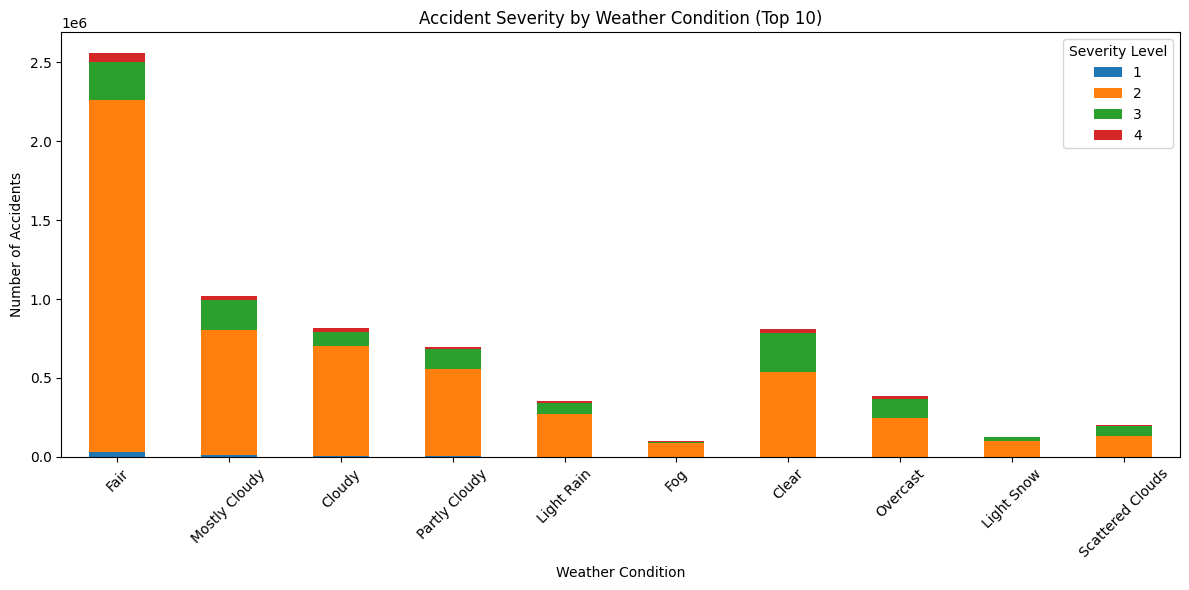

In [28]:
# Get the top 10 most common weather conditions
top_10_conditions = df['Weather_Condition'].value_counts().index[:10]

top_10_weather_condition = df[df['Weather_Condition'].isin(top_10_conditions)]

pivot_table = top_10_weather_condition.pivot_table(
    index='Weather_Condition',
    columns='Severity',
    values='ID',
    aggfunc='count',
    fill_value=0  
).sort_values(by=1, ascending=False)

pivot_table.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Accident Severity by Weather Condition (Top 10)")
plt.ylabel("Number of Accidents")
plt.xlabel("Weather Condition")
plt.legend(title="Severity Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Inference:

-> Fair weather accounts for the highest number of accidents by far (over 2.3 million in the top conditions), with the vast majority classified as severity level 2 — indicating that the largest volume of incidents occurs under seemingly ideal driving conditions.

-> Cloudy-related conditions (Mostly Cloudy, Cloudy, Partly Cloudy) rank as the next most frequent, collectively showing a similar dominance of severity level 2, but with slightly higher proportions of level 3 (moderate severity) compared to fair weather.

-> Adverse weather conditions such as Light Rain, Fog, and Light Snow appear much lower in total accident count and show relatively higher shares of severity level 3 and 4, suggesting that while these conditions produce fewer crashes overall, the crashes that do occur tend to be more severe.

-> Clear weather ranks surprisingly high in accident volume (comparable to some cloudy conditions), reinforcing that visibility alone does not guarantee safety — human factors, traffic density, and behavior likely play a larger role than weather in most incidents.

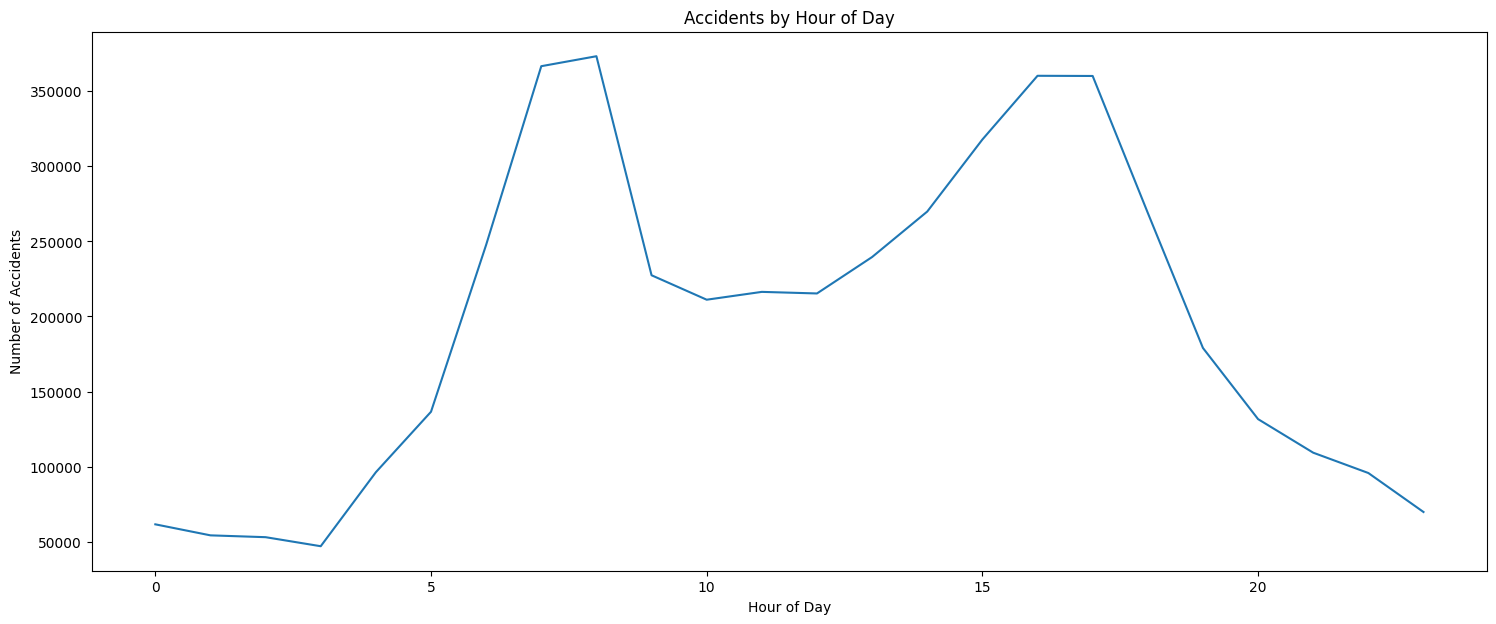

In [36]:
# Accidents by Hour of Day
df_of_accident_prone_cities['Start_Time'] = pd.to_datetime(
    df_of_accident_prone_cities['Start_Time'], errors='coerce'
)

df_of_accident_prone_cities['Hour'] = df_of_accident_prone_cities['Start_Time'].dt.hour

hourly_accidents = df_of_accident_prone_cities.groupby('Hour').size()

hourly_accidents.plot(kind='line', figsize=(18,7))
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.title("Accidents by Hour of Day")
plt.show()

# Inferences:

-> Accident frequency peaks during morning (7–9 AM) and evening (4–7 PM).

-> These periods correspond to daily commuting hours, indicating that traffic congestion significantly increases accident risk.

-> Lower accident frequency is observed between 1 AM – 5 AM, suggesting reduced traffic volume.

-> This insight can help traffic authorities implement targeted safety measures during peak hours.

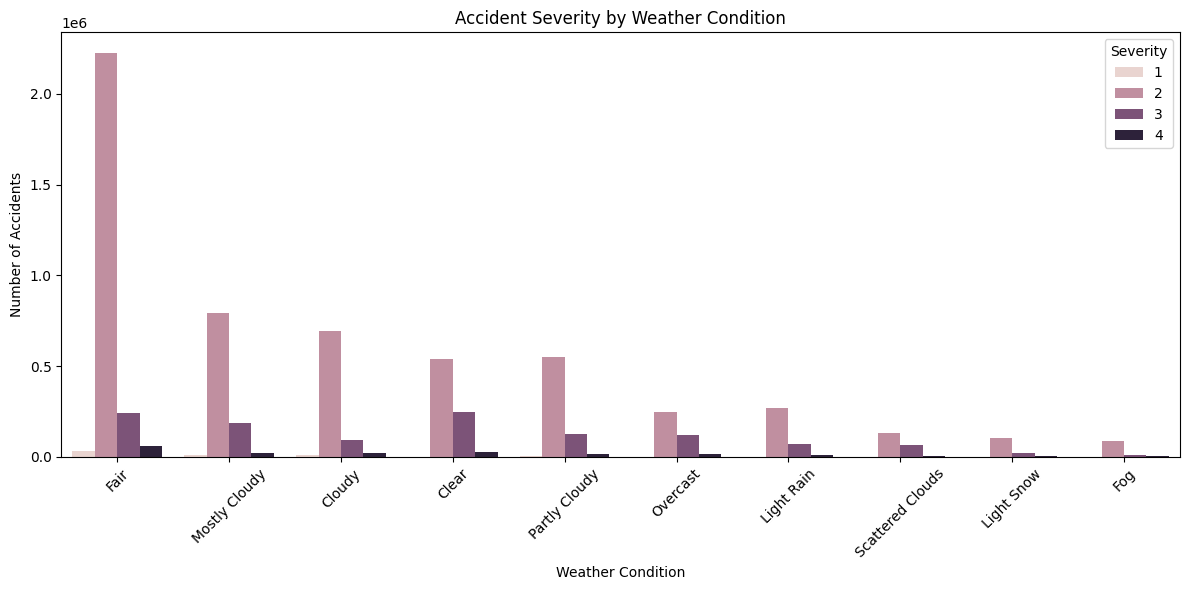

In [ ]:
# Weather Condition vs Accident Severity

top_weather = df['Weather_Condition'].value_counts().head(10).index

df_weather = df[df['Weather_Condition'].isin(top_weather)]

plt.figure(figsize=(12,6))

sns.countplot(
    data=df_weather,
    x='Weather_Condition',
    hue='Severity',
    order=top_weather
)

plt.xticks(rotation=45)
plt.title("Accident Severity by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")

plt.legend(title="Severity")
plt.tight_layout()

plt.show()


# Inference

-> A large number of accidents occur during clear weather conditions, indicating that accidents are primarily driven by traffic density rather than weather alone.

-> However, fog, rain, and snow show a higher proportion of severe accidents, suggesting reduced visibility significantly increases accident severity.

-> This highlights the need for enhanced driver awareness and traffic management during adverse weather conditions.

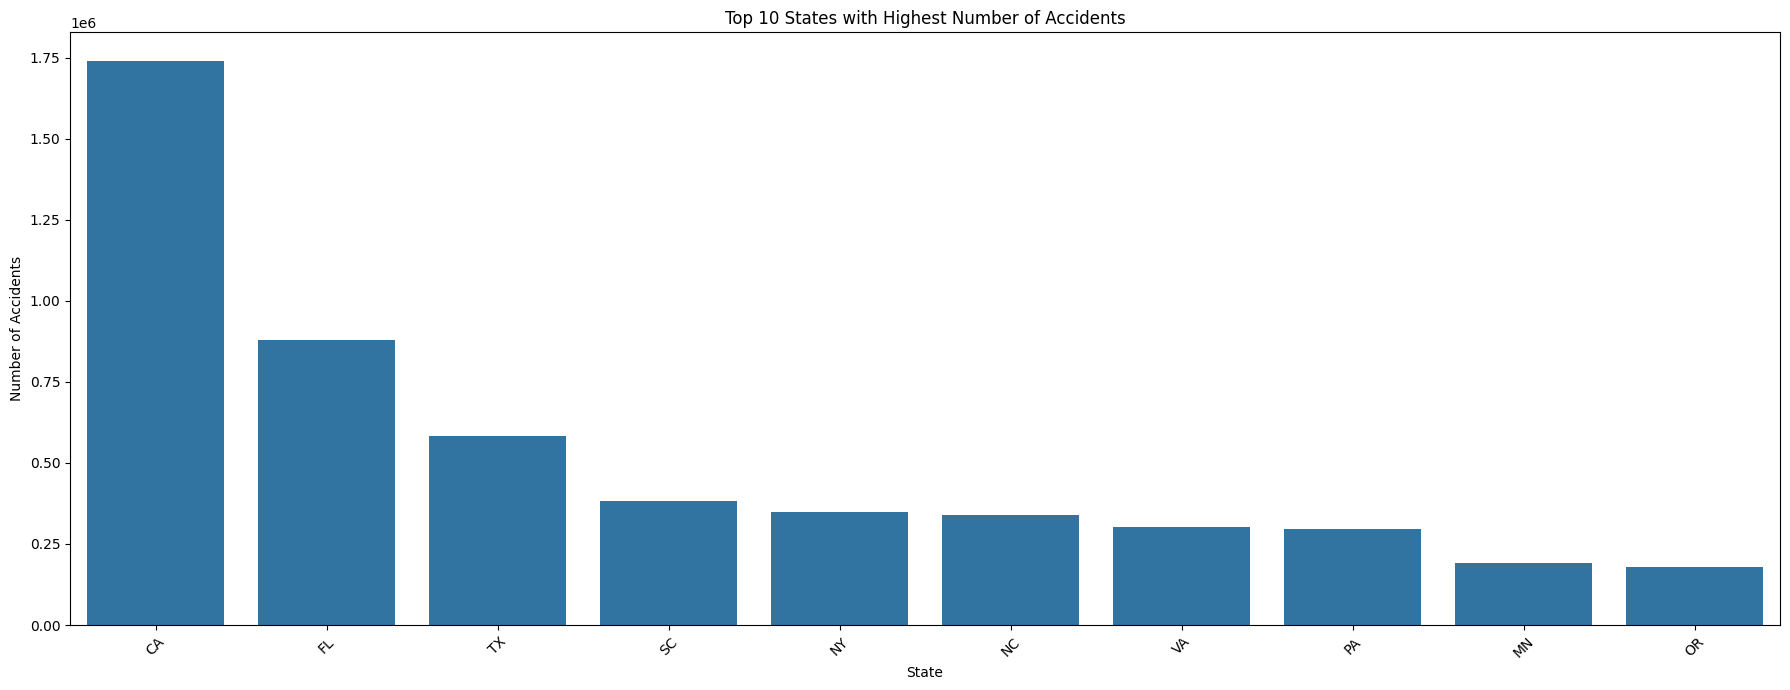

In [ ]:
# Top 10 states with most accidents
state_accidents = df['State'].value_counts().head(10)

plt.figure(figsize=(18,7))
sns.barplot(x=state_accidents.index, y=state_accidents.values)

plt.title("Top 10 States with Highest Number of Accidents")
plt.xlabel("State")
plt.ylabel("Number of Accidents")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Inference

-> States like California, Texas, and Florida report the highest number of accidents.

-> These states have large populations, extensive highway networks, and high vehicle density, which contribute to increased accident frequency.

-> Identifying such hotspots can help policymakers prioritize road safety initiatives and infrastructure improvements in high-risk regions.